# Rappi - Caso Growth Senior Analyst
## Módulo 1 - Diagnóstico Operacional




In [ ]:
# 0. Instalación de librerías — Google Colab
!pip -q install pandas openpyxl scipy statsmodels matplotlib shapely requests


In [ ]:
# 1. Carga del Excel
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, spearmanr
from pathlib import Path

uploaded = files.upload()
excel_files = [x for x in uploaded.keys() if x.lower().endswith((".xlsx", ".xls"))]

if not excel_files:
    raise FileNotFoundError("No se encontró un Excel. Sube el archivo original del caso.")

PATH = excel_files[0]

raw = pd.read_excel(PATH, sheet_name="RAW_DATA")
zone_info = pd.read_excel(PATH, sheet_name="ZONE_INFO")

df = raw.copy()
df["DATE"] = pd.to_datetime(df["DATE"])

print(f"Archivo cargado: {PATH}")
print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
df.head()


Saving rappi_delivery_case_data.xlsx to rappi_delivery_case_data.xlsx
Archivo cargado: rappi_delivery_case_data.xlsx
Filas: 10,080
Columnas: 9


,COUNTRY,DATE,HOUR,CITY,ZONE,CONNECTED_RT,ORDERS,EARNINGS,PRECIPITATION_MM
0,Mexico,2024-03-01,0,Monterrey,Centro,6,2,54.4,0.0
1,Mexico,2024-03-01,0,Monterrey,Mitras Centro,5,1,52.4,0.0
2,Mexico,2024-03-01,0,Monterrey,Apodaca Centro,4,1,59.1,0.0
3,Mexico,2024-03-01,0,Monterrey,Escobedo,3,1,53.3,0.0
4,Mexico,2024-03-01,0,Monterrey,Carretera Nacional,2,0,55.0,0.0



El caso define `RATIO < 0.5` como sobre-oferta, `0.9–1.2` como rango saludable y `>1.8` como saturación.


In [ ]:
# 2. Métricas centrales

df["RATIO"] = df["ORDERS"] / df["CONNECTED_RT"]
df["SATURATION"] = df["RATIO"] > 1.8
df["OVERSUPPLY"] = df["RATIO"] < 0.5

print("Ratio promedio:", round(df["RATIO"].mean(), 3))
print("Saturación:", round(df["SATURATION"].mean()*100, 2), "%")
print("Sobre-oferta:", round(df["OVERSUPPLY"].mean()*100, 2), "%")


Ratio promedio: 0.818
Saturación: 5.09 %
Sobre-oferta: 22.39 %


Se creo la metrica central del caso

**Ratio = Órdenes / Repartidores conectados**

Ejemplo:

`20 órdenes / 10 repartidores = 2.0`

Como `2.0 > 1.8`, esa observación es **saturación**.


# P1. ¿En qué horas y zonas hay mayor saturación?

Primero analizamos la saturación por hora y después por la combinación **zona + hora**.

La métrica principal será `saturation_pct`, pero también miraremos `avg_ratio` para no depender de una sola medida.


,HOUR,avg_ratio,saturation_rate,observations,saturation_pct
14,14,1.596,0.279,420,27.857
13,13,1.525,0.260,420,25.952
12,12,1.521,0.245,420,24.524
21,21,1.396,0.162,420,16.190
19,19,1.366,0.124,420,12.381
20,20,1.362,0.121,420,12.143
17,17,0.838,0.010,420,0.952
16,16,0.824,0.007,420,0.714
22,22,0.993,0.005,420,0.476
18,18,0.846,0.005,420,0.476


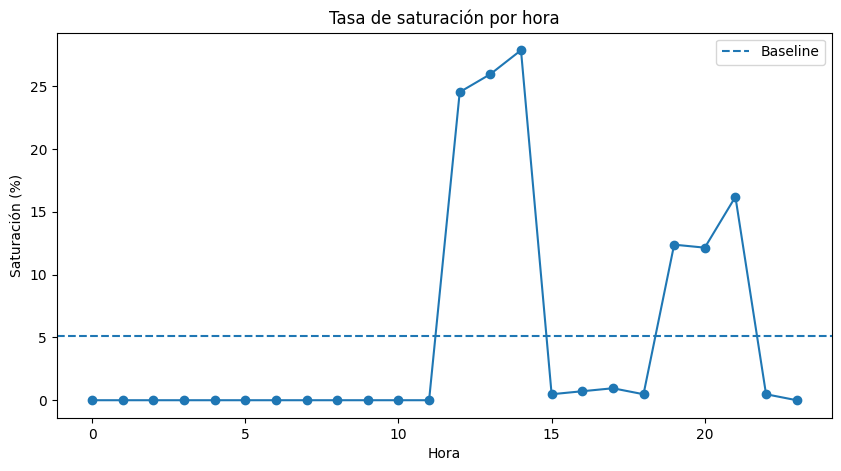

In [ ]:
# P1A. Saturación por hora

overall_saturation = df["SATURATION"].mean()

hour_summary = (
    df.groupby("HOUR")
      .agg(
          avg_ratio=("RATIO", "mean"),
          saturation_rate=("SATURATION", "mean"),
          observations=("RATIO", "size")
      )
      .reset_index()
)

hour_summary["saturation_pct"] = hour_summary["saturation_rate"] * 100

display(
    hour_summary
    .sort_values(["saturation_rate", "avg_ratio"], ascending=False)
    .round(3)
)

plt.figure(figsize=(10,5))
plt.plot(hour_summary["HOUR"], hour_summary["saturation_pct"], marker="o")
plt.axhline(overall_saturation*100, linestyle="--", label="Baseline")
plt.title("Tasa de saturación por hora")
plt.xlabel("Hora")
plt.ylabel("Saturación (%)")
plt.legend()
plt.show()


### ¿Qué se encontró en P1A?

- `saturation_pct` = porcentaje de observaciones saturadas en cada hora.
- `avg_ratio` = ratio promedio de esa hora.
- `baseline` = tasa de saturación promedio de toda la operación.

La pregunta de negocio es **cuándo se concentra el riesgo**.

No debemos quedarnos únicamente con el ratio promedio: la frecuencia con que se cruza el umbral de saturación también importa.

### Conexión con Módulo 2

Las horas históricamente críticas pueden utilizarse como una señal adicional en el motor:

**Hora crítica + condición climática → mayor riesgo esperado.**

El caso pide cuantificar las horas críticas.


,ZONE,HOUR,avg_ratio,saturation_rate,observations,avg_orders,avg_connected,saturation_pct
206,MTY_Guadalupe,14,1.658,0.400,30,32.033,20.700,40.000
229,Mitras Centro,13,1.617,0.400,30,30.233,19.933,40.000
254,San Nicolás,14,1.734,0.367,30,34.833,21.867,36.667
260,San Nicolás,20,1.480,0.367,30,31.900,23.067,36.667
38,Carretera Nacional,14,1.665,0.333,30,16.367,10.900,33.333
60,Centro,12,1.546,0.333,30,41.833,28.867,33.333
61,Centro,13,1.496,0.333,30,44.167,31.600,33.333
326,Santiago,14,1.743,0.300,30,12.667,8.333,30.000
110,Escobedo,14,1.624,0.300,30,21.167,14.033,30.000
13,Apodaca Centro,13,1.580,0.300,30,25.733,17.500,30.000


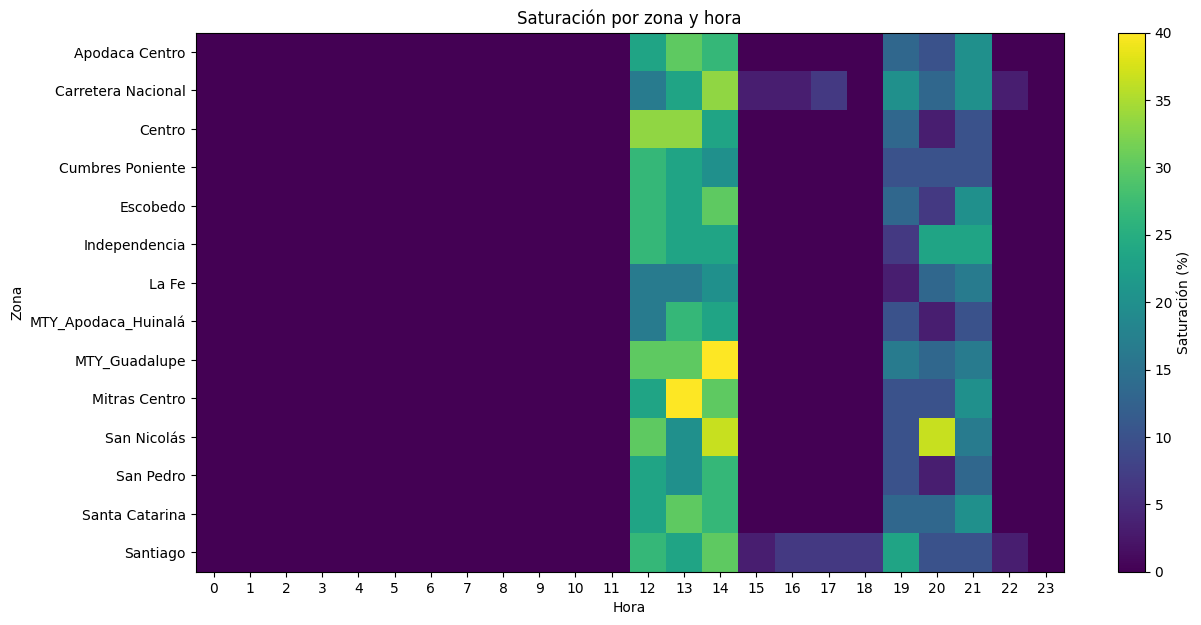

In [ ]:
# P1B. Saturación por zona + hora

zone_hour = (
    df.groupby(["ZONE", "HOUR"])
      .agg(
          avg_ratio=("RATIO", "mean"),
          saturation_rate=("SATURATION", "mean"),
          observations=("RATIO", "size"),
          avg_orders=("ORDERS", "mean"),
          avg_connected=("CONNECTED_RT", "mean")
      )
      .reset_index()
)

zone_hour["saturation_pct"] = zone_hour["saturation_rate"] * 100

top_zone_hours = (
    zone_hour
    .sort_values(["saturation_rate", "avg_ratio"], ascending=False)
    .head(15)
)

display(top_zone_hours.round(3))

pivot = zone_hour.pivot(index="ZONE", columns="HOUR", values="saturation_pct")

plt.figure(figsize=(14,7))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Saturación (%)")
plt.title("Saturación por zona y hora")
plt.xlabel("Hora")
plt.ylabel("Zona")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.show()




### Insight

El sistema futuro debería considerar **zona + hora**, no solamente una regla global para toda la ciudad.


# P2. ¿Qué variable externa se relaciona con el deterioro del ratio?

La variable externa disponible es `PRECIPITATION_MM`.

Vamos a utilizar:
1. Pearson.
2. Spearman.
3. OLS controlando por hora y zona.
4. Buckets de lluvia.
5. Comparación en la ventana crítica 12–14hrs


In [ ]:
# P2A. Pearson y Spearman

pearson_r, pearson_p = pearsonr(
    df["PRECIPITATION_MM"], df["RATIO"]
)

spearman_r, spearman_p = spearmanr(
    df["PRECIPITATION_MM"], df["RATIO"]
)

print("PEARSON")
print("r =", round(pearson_r, 3))
print("p-value =", f"{pearson_p:.3e}")

print("\nSPEARMAN")
print("rho =", round(spearman_r, 3))
print("p-value =", f"{spearman_p:.3e}")


PEARSON
r = 0.319
p-value = 4.908e-237

SPEARMAN
rho = 0.231
p-value = 6.482e-122


**Interpretación**

**Pearson** = 0.319: relación positiva moderada entre lluvia y ratio.  
**Spearman** = 0.231: confirma una relación positiva, aunque más débil.           
Por qué ambos? Pearson evalúa la relación lineal y Spearman permite comprobar que el patrón no dependa de asumir linealidad.
**Conclusión:** ambos resultados sugieren que mayores niveles de lluvia están asociados con un mayor ratio operacional. Para aislar mejor este efecto, se utiliza posteriormente un modelo que controla por hora y zona.

In [ ]:
# P2B. OLS ajustado por hora y zona

rain_model = smf.ols(
    "RATIO ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)",
    data=df
).fit()

rain_coef = rain_model.params["PRECIPITATION_MM"]
rain_p = rain_model.pvalues["PRECIPITATION_MM"]
r_squared = rain_model.rsquared

print("Coeficiente precipitación:", round(rain_coef, 4))
print("p-value:", f"{rain_p:.3e}")
print("R²:", round(r_squared, 3))


Coeficiente precipitación: 0.0806
p-value: 4.255e-240
R²: 0.717



`Ratio ~ Lluvia + Hora + Zona`

Es decir, intentamos estimar la asociación de la lluvia **controlando estadísticamente por hora y zona**.

El resultado anterior fue aproximadamente:

**Coeficiente de precipitación = 0.0806**

Interpretación:

Un aumento de 1 mm/hr de precipitación se asocia con aproximadamente +0.081 unidades del ratio dentro del modelo, manteniendo constantes hora y zona.

### Conclusión

La asociación de precipitación con el ratio permanece después de incorporar hora y zona, pero sigue siendo un análisis observacional: **no demuestra causalidad**.


,RAIN_BIN,observations,avg_ratio,saturation_rate,avg_orders,avg_connected,saturation_pct
0,0,9464,0.775,0.037,8.867,8.940,3.677
1,0–0.5,126,0.893,0.111,9.516,7.167,11.111
2,0.5–1,56,1.075,0.214,11.893,10.161,21.429
3,1–2,70,1.800,0.414,18.800,11.500,41.429
4,2–5,140,1.540,0.243,19.929,13.336,24.286
5,5+,224,1.769,0.339,23.504,15.183,33.929


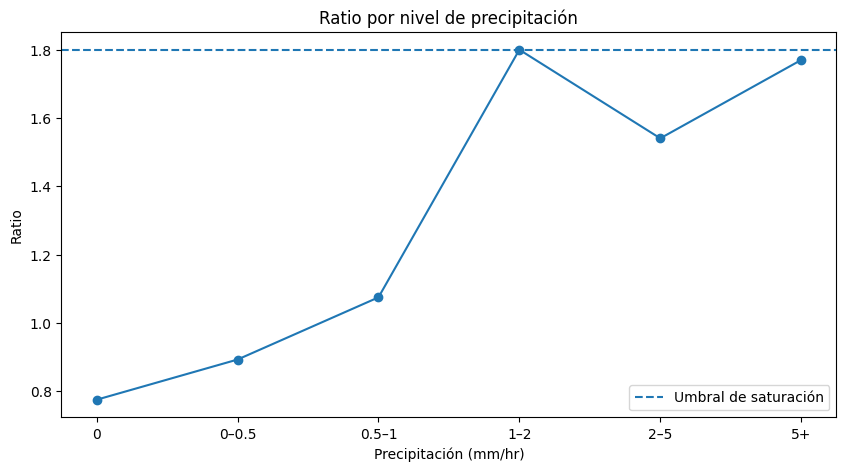

In [ ]:
# P2C. Buckets de precipitación

rain_bins = pd.cut(
    df["PRECIPITATION_MM"],
    bins=[-0.001, 0, 0.5, 1, 2, 5, np.inf],
    labels=["0", "0–0.5", "0.5–1", "1–2", "2–5", "5+"]
)

rain_summary = (
    df.assign(RAIN_BIN=rain_bins)
      .groupby("RAIN_BIN", observed=True)
      .agg(
          observations=("RATIO", "size"),
          avg_ratio=("RATIO", "mean"),
          saturation_rate=("SATURATION", "mean"),
          avg_orders=("ORDERS", "mean"),
          avg_connected=("CONNECTED_RT", "mean")
      )
      .reset_index()
)

rain_summary["saturation_pct"] = rain_summary["saturation_rate"] * 100

display(rain_summary.round(3))

plt.figure(figsize=(10,5))
plt.plot(rain_summary["RAIN_BIN"].astype(str), rain_summary["avg_ratio"], marker="o")
plt.axhline(1.8, linestyle="--", label="Umbral de saturación")
plt.title("Ratio por nivel de precipitación")
plt.xlabel("Precipitación (mm/hr)")
plt.ylabel("Ratio")
plt.legend()
plt.show()



Conclusión:

Los niveles altos de precipitación están asociados con mayor riesgo operacional, pero la relación no es perfectamente lineal y depende del contexto.


In [ ]:
# P2D. Mecanismo durante 12–14

critical_window = [12, 13, 14]

peak = df[df["HOUR"].isin(critical_window)].copy()
peak["RAIN_GT_1"] = peak["PRECIPITATION_MM"] > 1

mechanism = (
    peak.groupby("RAIN_GT_1")
        .agg(
            observations=("RATIO", "size"),
            avg_ratio=("RATIO", "mean"),
            saturation_rate=("SATURATION", "mean"),
            avg_orders=("ORDERS", "mean"),
            avg_connected=("CONNECTED_RT", "mean")
        )
        .rename(index={
            False: "Lluvia <= 1 mm/hr",
            True: "Lluvia > 1 mm/hr"
        })
)

display(mechanism.round(3))

low = mechanism.loc["Lluvia <= 1 mm/hr"]
high = mechanism.loc["Lluvia > 1 mm/hr"]

print("Cambio ratio:", round((high.avg_ratio / low.avg_ratio - 1)*100, 1), "%")
print("Cambio órdenes:", round((high.avg_orders / low.avg_orders - 1)*100, 1), "%")
print("Cambio repartidores:", round((high.avg_connected / low.avg_connected - 1)*100, 1), "%")
print(
    "Cambio saturación:",
    round((high.saturation_rate - low.saturation_rate)*100, 1),
    "puntos porcentuales"
)


,observations,avg_ratio,saturation_rate,avg_orders,avg_connected
RAIN_GT_1,,,,,
Lluvia <= 1 mm/hr,1134,1.464,0.216,25.302,18.297
Lluvia > 1 mm/hr,126,2.298,0.667,29.833,14.262


Cambio ratio: 56.9 %
Cambio órdenes: 17.9 %
Cambio repartidores: -22.1 %
Cambio saturación: 45.1 puntos porcentuales


### Conclusión:

De 12–14 hrs, las observaciones con lluvia >1 mm/hr mostraron:

- Ratio: **1.464 → 2.298**
- Órdenes: **25.3 → 29.8**
- RTs conectados: **18.3 → 14.3**
- Saturación: **21.6% → 66.7%**




# P3. ¿Todas las zonas responden igual a la lluvia?

Ahora queremos medir la sensibilidad de cada zona.

Para cada zona estimamos:

`Ratio ~ Precipitación + Hora`

Así aislamos parcialmente el efecto de la hora y podemos comparar la sensibilidad entre zonas.


,ZONE,rain_slope,p_value,r_squared
13,Santiago,0.1915,0.0,0.8013
1,Carretera Nacional,0.1339,0.0,0.8456
12,Santa Catarina,0.1026,0.0,0.6981
7,MTY_Apodaca_Huinalá,0.0847,0.0,0.8356
5,Independencia,0.0748,0.0,0.7033
11,San Pedro,0.0670,0.0,0.7680
4,Escobedo,0.0668,0.0,0.6460
0,Apodaca Centro,0.0658,0.0,0.7448
2,Centro,0.0610,0.0,0.7611
6,La Fe,0.0590,0.0,0.6260


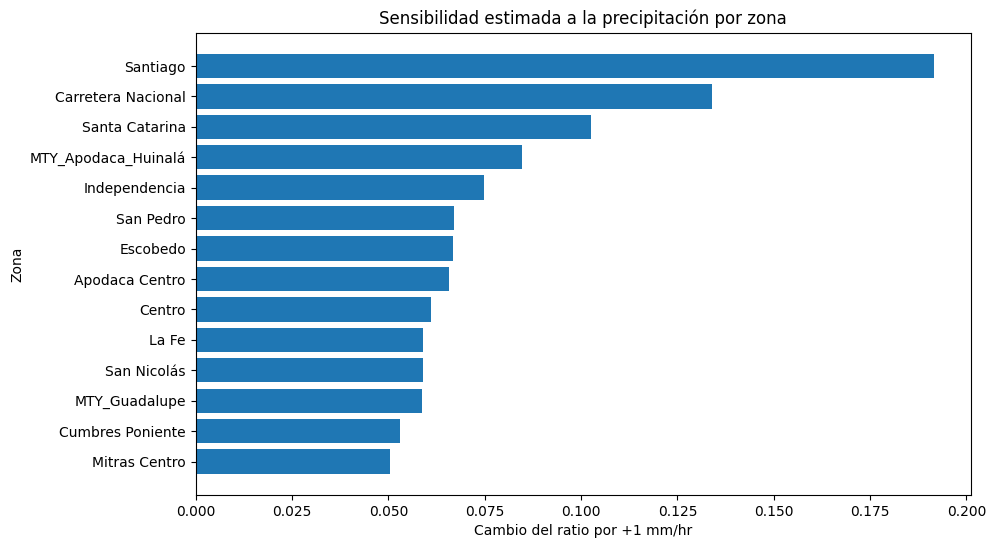

In [ ]:
# P3. Sensibilidad por zona

zone_sensitivity = []

for zone, group in df.groupby("ZONE"):
    model = smf.ols(
        "RATIO ~ PRECIPITATION_MM + C(HOUR)",
        data=group
    ).fit()

    zone_sensitivity.append({
        "ZONE": zone,
        "rain_slope": model.params.get("PRECIPITATION_MM", np.nan),
        "p_value": model.pvalues.get("PRECIPITATION_MM", np.nan),
        "r_squared": model.rsquared
    })

zone_sensitivity = (
    pd.DataFrame(zone_sensitivity)
      .sort_values("rain_slope", ascending=False)
)

display(zone_sensitivity.round(4))

plt.figure(figsize=(10,6))
ordered = zone_sensitivity.sort_values("rain_slope")
plt.barh(ordered["ZONE"], ordered["rain_slope"])
plt.title("Sensibilidad estimada a la precipitación por zona")
plt.xlabel("Cambio del ratio por +1 mm/hr")
plt.ylabel("Zona")
plt.show()



`rain_slope` representa el cambio estimado del ratio ante **+1 mm/hr de precipitación**, controlando por hora dentro de cada zona.



### Conclusión:

No todas las zonas responden igual.

Por lo tanto, el motor no debería aplicar necesariamente:

```text
Si lluvia > 1 mm/hr → alerta para toda la ciudad
```

sino algo más contextual:

```text
Zona + hora + lluvia
        ↓
riesgo específico
```

# P4. ¿El nivel de earnings está bien calibrado?

Buscamos días donde haya:

- earnings relativamente altos
- poca lluvia
- y saturación igual o inferior al baseline



In [ ]:
# P4. Análisis diario

daily = (
    df.groupby("DATE")
      .agg(
          avg_earnings=("EARNINGS", "mean"),
          median_earnings=("EARNINGS", "median"),
          avg_ratio=("RATIO", "mean"),
          saturation_rate=("SATURATION", "mean"),
          avg_rain=("PRECIPITATION_MM", "mean"),
          total_orders=("ORDERS", "sum"),
          avg_connected=("CONNECTED_RT", "mean")
      )
      .reset_index()
)

earnings_q75 = daily["avg_earnings"].quantile(0.75)

potentially_inefficient = daily[
    (daily["avg_earnings"] >= earnings_q75) &
    (daily["avg_rain"] < 0.1) &
    (daily["saturation_rate"] <= overall_saturation)
].sort_values("DATE")

print("Q75 earnings:", round(earnings_q75, 2))
display(potentially_inefficient.round(3))


Q75 earnings: 57.34


,DATE,avg_earnings,median_earnings,avg_ratio,saturation_rate,avg_rain,total_orders,avg_connected
2,2024-03-03,60.749,55.95,0.747,0.036,0.000,3097,10.042
6,2024-03-07,59.742,56.15,0.760,0.033,0.029,3095,9.878
10,2024-03-11,57.378,55.70,0.794,0.045,0.000,3116,9.131
13,2024-03-14,60.445,56.00,0.746,0.051,0.000,3111,9.982
21,2024-03-22,61.064,56.70,0.737,0.039,0.000,3096,10.217



La regla identifica:

```text
Earnings >= Q75
+
Poca lluvia
+
Saturación <= baseline
```

Podrían existir periodos donde pagamos incentivos relativamente altos sin una presión operacional equivalente.
Pero **no debemos llamar automáticamente a esos días “gasto ineficiente”**.
Podrían existir factores que no observamos en el dataset.
Estos días deben pasar a una lista de **revisión de eficiencia de incentives**.



# P5. ¿Qué relación tiene earnings con la saturación?

Analizaremos earnings por cuartiles y luego una regresión logística ajustada.


In [ ]:
# P5A. Earnings por cuartiles durante 12–14

critical = df[df["HOUR"].isin(critical_window)].copy()

critical["EARNINGS_Q"] = pd.qcut(
    critical["EARNINGS"],
    4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

earnings_summary = (
    critical.groupby("EARNINGS_Q", observed=True)
            .agg(
                observations=("RATIO", "size"),
                avg_earnings=("EARNINGS", "mean"),
                avg_ratio=("RATIO", "mean"),
                saturation_rate=("SATURATION", "mean"),
                avg_rain=("PRECIPITATION_MM", "mean"),
                avg_connected=("CONNECTED_RT", "mean"),
                avg_orders=("ORDERS", "mean")
            )
            .reset_index()
)

earnings_summary["saturation_pct"] = earnings_summary["saturation_rate"] * 100

display(earnings_summary.round(3))


,EARNINGS_Q,observations,avg_earnings,avg_ratio,saturation_rate,avg_rain,avg_connected,avg_orders,saturation_pct
0,Q1,316,52.575,2.014,0.687,0.408,13.278,26.174,68.671
1,Q2,315,58.064,1.803,0.346,0.737,14.559,25.587,34.603
2,Q3,316,70.248,1.251,0.009,0.310,20.544,25.456,0.949
3,Q4,313,75.317,1.118,0.000,0.313,23.233,25.802,0.000



Dividimos earnings en cuatro grupos:

```text
Q1 → earnings bajos
Q2
Q3
Q4 → earnings altos
```

Luego observamos la saturación. Esto permite ver si existe una tendencia.
Operations puede aumentar earnings **porque ya anticipa riesgo**:

```text
Riesgo esperado ↑
      ↓
Operations sube earnings
      ↓
observamos earnings altos
```

Por eso una relación observada entre earnings y saturación puede estar confundida por la decisión operacional.

Esta es una razón para no interpretar una correlación simple como causalidad.


In [ ]:
# P5B. Modelo logístico

df["SATURATION_BIN"] = df["SATURATION"].astype(int)

logit_model = smf.logit(
    "SATURATION_BIN ~ EARNINGS + PRECIPITATION_MM + C(HOUR) + C(ZONE)",
    data=df
).fit(disp=False)

logit_results = pd.DataFrame({
    "coeficiente": logit_model.params,
    "odds_ratio": np.exp(logit_model.params),
    "p_value": logit_model.pvalues
})

display(
    logit_results.loc[
        ["EARNINGS", "PRECIPITATION_MM"]
    ].round(4)
)


,coeficiente,odds_ratio,p_value
EARNINGS,-0.4274,0.6522,0.0
PRECIPITATION_MM,1.0476,2.8508,0.0


## Principales hallazgos

1. **12–14hrs es la principal ventana de riesgo**, a las 14:00 como punto especialmente crítico.
2. **La precipitación está positivamente asociada con el ratio**, incluso después de controlar por hora y zona.
3. **El riesgo es heterogéneo por zona:** Santiago, Carretera Nacional y Santa Catarina presentan mayor sensibilidad histórica a la lluvia.
4. Existen días con **earnings relativamente altos sin presión operacional equivalente** que deben pasar a revisión de eficiencia.
5. La relación entre **earnings y saturación depende del contexto** y no debe interpretarse como una regla causal simple.

## Cómo se conecta con el Módulo 2

Los hallazgos del diagnóstico sirven como insumo para:

- priorizar **hora + zona**;
- definir un **trigger climático inicial**;
- incorporar **sensibilidad por zona**;
- contextualizar la recomendación de **earnings**.

